In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("amazon_sales_large_dataset_5000.csv")

# Display first 5 rows
df.head()

,Order_ID,Order_Date,Customer_Name,Product,Category,Price,Quantity,Discount,Sales,Profit,City,State,Payment_Method
0,100001,2026-04-06,Customer_1,T-Shirt,Clothing,599,5,0,2995.00,535.10,Mumbai,Maharashtra,Cash on Delivery
1,100002,2026-02-04,Customer_2,Jeans,Clothing,1299,2,0,2598.00,603.27,Kochi,Kerala,Cash on Delivery
2,100003,2025-08-23,Customer_3,Laptop Bag,Electronics,1999,1,15,1699.15,307.98,Kochi,Kerala,Net Banking
3,100004,2025-01-10,Customer_4,Keyboard,Electronics,1499,3,0,4497.00,562.73,Pune,Maharashtra,Cash on Delivery
4,100005,2026-03-25,Customer_5,Cookware Set,Home & Kitchen,2499,4,0,9996.00,2412.58,Kochi,Kerala,Cash on Delivery


In [5]:
df.shape

(5000, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        5000 non-null   int64  
 1   Order_Date      5000 non-null   object 
 2   Customer_Name   5000 non-null   object 
 3   Product         5000 non-null   object 
 4   Category        5000 non-null   object 
 5   Price           5000 non-null   int64  
 6   Quantity        5000 non-null   int64  
 7   Discount        5000 non-null   int64  
 8   Sales           5000 non-null   float64
 9   Profit          5000 non-null   float64
 10  City            5000 non-null   object 
 11  State           5000 non-null   object 
 12  Payment_Method  5000 non-null   object 
dtypes: float64(2), int64(4), object(7)
memory usage: 507.9+ KB


In [7]:
df.describe()

,Order_ID,Price,Quantity,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,102500.500000,1825.420000,3.024800,9.984000,4962.650710,1159.849430
std,1443.520003,1410.699826,1.412014,7.087298,4833.750939,1211.221618
min,100001.000000,399.000000,1.000000,0.000000,319.200000,42.940000
25%,101250.750000,699.000000,2.000000,5.000000,1598.000000,361.922500
50%,102500.500000,1299.000000,3.000000,10.000000,3145.500000,721.445000
75%,103750.250000,2499.000000,4.000000,15.000000,6745.500000,1514.045000
max,105000.000000,4999.000000,5.000000,20.000000,24995.000000,8463.950000


In [8]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_Name     0
Product           0
Category          0
Price             0
Quantity          0
Discount          0
Sales             0
Profit            0
City              0
State             0
Payment_Method    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.dtypes

Order_ID            int64
Order_Date         object
Customer_Name      object
Product            object
Category           object
Price               int64
Quantity            int64
Discount            int64
Sales             float64
Profit            float64
City               object
State              object
Payment_Method     object
dtype: object

In [14]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Books              1506761.55
Clothing           2713734.30
Electronics       12647579.25
Home & Kitchen     7945178.45
Name: Sales, dtype: float64


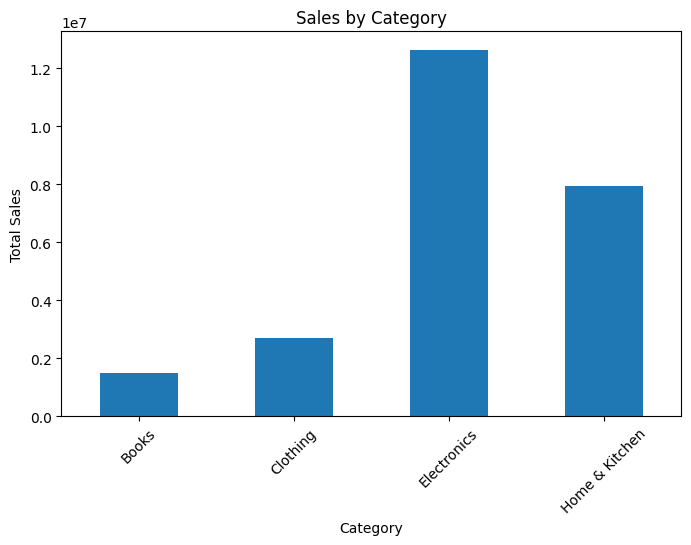

In [15]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [16]:
print("Average Sales:", df["Sales"].mean())

Average Sales: 4962.65071


In [17]:
print("Average Sales:", df["Sales"].mean())

Average Sales: 4962.65071


In [18]:
top_products = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product
Smart Watch       7036842.35
Mixer Grinder     4658743.55
Cookware Set      3286434.90
Laptop Bag        2625786.45
Keyboard          1867229.35
Jeans             1861596.90
Wireless Mouse    1117721.10
Python Book        964899.60
T-Shirt            852137.40
Novel              541861.95
Name: Sales, dtype: float64


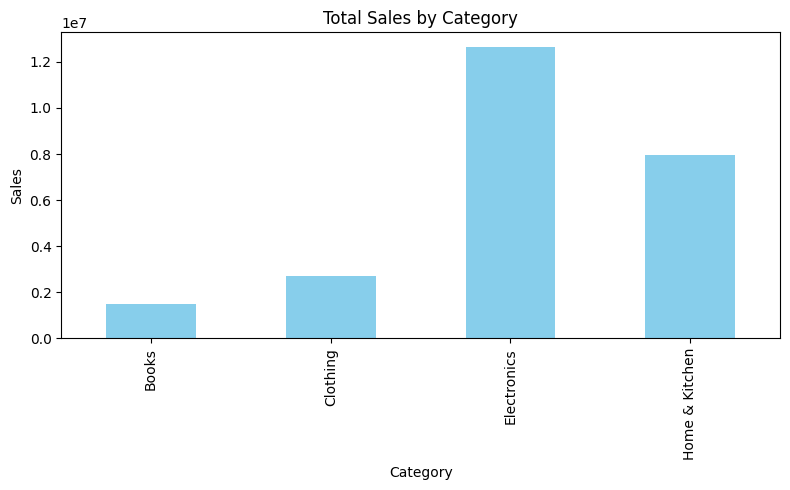

In [21]:
plt.figure(figsize=(8,5))
df.groupby("Category")["Sales"].sum().plot(kind="bar", color="skyblue")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("charts/sales_by_category.png")
plt.show()

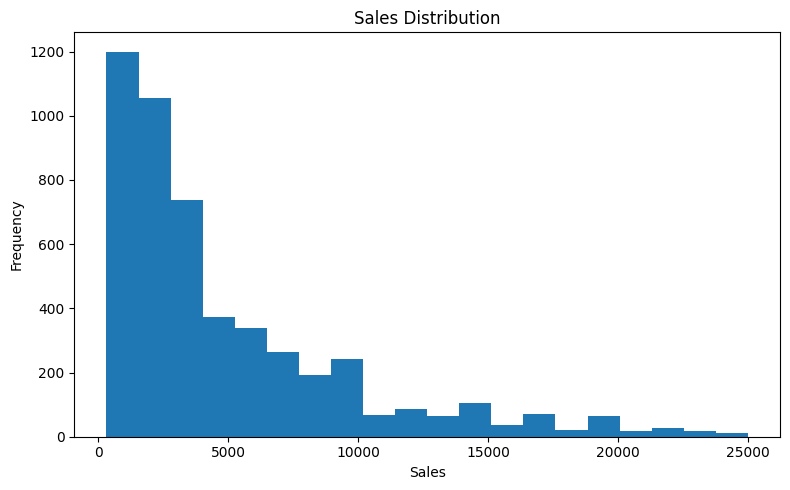

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("charts/sales_distribution.png")
plt.show()

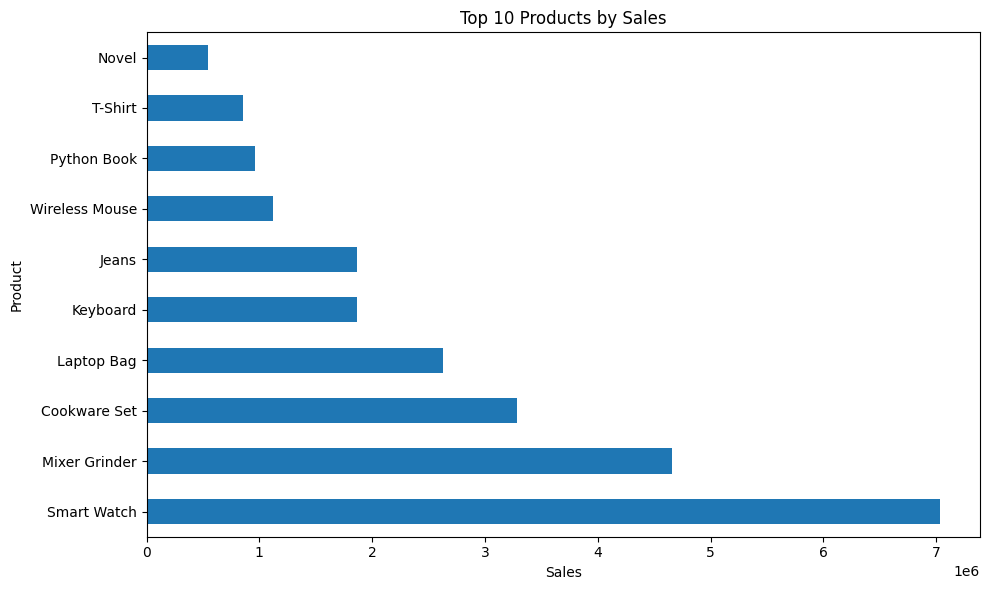

In [25]:
top_products = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.savefig("charts/top_products.png")
plt.show()